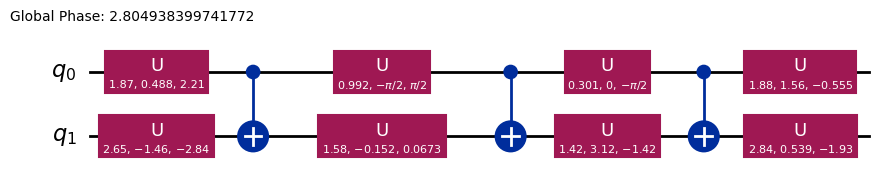

In [6]:
import numpy as np
CZ = np.asarray([[1,0,0,0],
                [0,1,0,0],
                [0,0,1,0],
                [0,0,0,-1]])
vec = np.asarray([0,0,1,0])

from qiskit.circuit.library import CXGate, CZGate, RZZGate

CX = CXGate().to_matrix()
CZ = CZGate().to_matrix()
RZZ = RZZGate(0.3).to_matrix()

from qiskit.synthesis import TwoQubitBasisDecomposer
from qiskit.quantum_info import Operator
from qiskit.circuit.library import CXGate

basis = CXGate()
decomposer = TwoQubitBasisDecomposer(CXGate())

import numpy as np
from qiskit.quantum_info import random_unitary

U = random_unitary(4)  # 4x4 = 2-qubit unitary
# Decompose
circ = decomposer(U)
circ.draw('mpl')


In [4]:
single_q_gate = {}
for instr in circ.data:
    op = instr.operation
    qubits = instr.qubits
    if op.num_qubits == 1:
        U = op.to_matrix()
        print(f"Single-qubit gate: {op.name} on qubit {qubits[0]}  params = {op.params}")
        print(U)
    elif op.num_qubits == 2:
        print(f"Two-qubit gate: {op.name} on qubits {[q for q in qubits]}")


Single-qubit gate: u on qubit <Qubit register=(2, "q"), index=0>  params = [0.8736274590237814, 1.2102360817711553, -1.3230563245900235]
[[ 0.90610423+0.j         -0.10373872+0.41013828j]
 [ 0.14925301+0.39585183j  0.90034371-0.10201017j]]
Single-qubit gate: u on qubit <Qubit register=(2, "q"), index=1>  params = [1.5750545011844548, -3.00194177383994, 1.2608239841796767]
[[ 0.70559969+0.j         -0.21614914-0.67483971j]
 [-0.7017121 -0.09863676j -0.11959856-0.69538989j]]
Two-qubit gate: cx on qubits [<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>]
Single-qubit gate: u on qubit <Qubit register=(2, "q"), index=0>  params = [1.0037975329465958, -1.5707963267948963, 1.5707963267948966]
[[ 8.76670663e-01+0.00000000e+00j -2.94583275e-17-4.81090998e-01j]
 [ 1.36281988e-16-4.81090998e-01j  8.76670663e-01+1.94659991e-16j]]
Single-qubit gate: u on qubit <Qubit register=(2, "q"), index=1>  params = [1.5947497007324083, -0.15018747261359255, 0.1569716175053899]
[[ 0.69858

In [8]:
import numpy as np
from qiskit.circuit.library import CXGate

# 1. Initialize the total unitary as a 4x4 Identity matrix
#    (We use 4x4 because you have 2 qubits: 2^2 = 4)
total_U = np.eye(4, dtype=complex)

# 2. Iterate through the instructions
for instr in circ.data:
    op = instr.operation
    qubits = instr.qubits
    # We assume the register is named 'q' based on your logs
    # q[0] is index 0, q[1] is index 1
    
    # Get the matrix for the current operation
    # Note: op.to_matrix() returns the gate's local matrix (2x2 for U, 4x4 for CX)
    gate_matrix = op.to_matrix()
    
    current_step_matrix = None

    if op.num_qubits == 1:
        # Determine which qubit the gate is acting on
        q_index = instr.qubits[0]._index
        
        if q_index == 0:
            # Gate is on q0, Identity on q1
            # Math: I (tensor) U
            current_step_matrix = np.kron(np.eye(2), gate_matrix)
        elif q_index == 1:
            # Gate is on q1, Identity on q0
            # Math: U (tensor) I
            current_step_matrix = np.kron(gate_matrix, np.eye(2))
            
    elif op.num_qubits == 2:
        # For the decomposition shown, it is usually a CX gate.
        # Qiskit's standard CXGate matrix assumes Control=0, Target=1 relative to the gate's wires.
        # We must check which qubit is control and which is target in the circuit.
        
        control_idx = qubits[0].index
        target_idx = qubits[1].index
        
        # If the instruction is exactly CX 0->1 (which fits your log)
        if control_idx == 0 and target_idx == 1:
            # In Little Endian (q1 tensor q0), CX 0->1 acts like this:
            # |00> -> |00>
            # |01> -> |11> (q0 is 1, so flip q1)
            # |10> -> |10>
            # |11> -> |01> (q0 is 1, so flip q1)
            # This creates the following matrix:
            current_step_matrix = np.array([
                [1, 0, 0, 0],
                [0, 0, 0, 1],
                [0, 0, 1, 0],
                [0, 1, 0, 0]
            ], dtype=complex)
        else:
            # If it were CX 1->0, the matrix would be different.
            # For a generic approach, Qiskit's Operator class handles this best,
            # but here is the manual matrix for CX 1->0 just in case:
            current_step_matrix = np.array([
                [1, 0, 0, 0],
                [0, 1, 0, 0],
                [0, 0, 0, 1],
                [0, 0, 1, 0]
            ], dtype=complex)

    # 3. Apply the matrix multiplication
    # Important: New operators are applied on the LEFT
    # U_total_new = U_current_gate @ U_total_old
    if current_step_matrix is not None:
        total_U = current_step_matrix @ total_U

print("Reconstructed Unitary Matrix:")
print(np.round(total_U, 3))

AttributeError: 'qiskit.circuit.Qubit' object has no attribute 'index'

In [ ]:
from qiskit.quantum_info import Operator

# Calculate using Qiskit's internal engine
true_U = Operator(circ).data

# Compare
are_matrices_equal = np.allclose(total_U, true_U)
print(f"Matches Qiskit Operator: {are_matrices_equal}")

In [5]:
def embed_1q_gate(mat, qubit_index, n_qubits=2):
    """
    Embed a 1-qubit gate acting on `qubit_index` into a 2-qubit Hilbert space.
    Qiskit indexing: qubit 0 is least significant bit → I ⊗ U
                     qubit 1 is most significant bit  → U ⊗ I
    """
    if n_qubits != 2:
        raise NotImplementedError("This helper is written for 2 qubits only.")

    if qubit_index == 0:
        return np.kron(np.eye(2), mat)   # I ⊗ U
    elif qubit_index == 1:
        return np.kron(mat, np.eye(2))   # U ⊗ I
    else:
        raise ValueError("qubit_index must be 0 or 1 for a 2-qubit circuit.")


U_reconstructed = np.eye(4, dtype=complex)

for instr in circ.data:
    op = instr.operation
    qubits = instr.qubits

    if op.num_qubits == 1:
        q_index = circ.qubits.index(qubits[0])  # map Qubit object → its index (0 or 1)
        op_full = embed_1q_gate(op.to_matrix(), q_index)
    elif op.num_qubits == 2:
        op_full = op.to_matrix()
    else:
        raise NotImplementedError("Expected only 1- and 2-qubit gates.")

    # IMPORTANT: apply in the same order as Qiskit:
    # first gate in data acts first → left-multiply
    U_reconstructed = op_full @ U_reconstructed

U_from_circ = Operator(circ).data

print("manual vs Operator(circ).data:", np.allclose(U_reconstructed, U_from_circ))
print("equiv up to phase:", Operator(U_reconstructed).equiv(Operator(U_from_circ)))


manual vs Operator(circ).data: False
equiv up to phase: True


In [3]:
from qiskit.quantum_info import Operator, random_unitary
from qiskit.circuit.library import CXGate
from qiskit.synthesis import TwoQubitBasisDecomposer

import numpy as np

basis = CXGate()
decomposer = TwoQubitBasisDecomposer(basis)

U_target = random_unitary(4)              # 2-qubit unitary
circ = decomposer(Operator(U_target))

U_from_circ = Operator(circ).data        # Qiskit’s unitary from the circuit
U_target_mat = U_target.data             # original unitary matrix

print("allclose raw:", np.allclose(U_from_circ, U_target_mat))


allclose raw: True


In [1]:
import numpy as np
import plotly.graph_objects as go

# Points
I       = (0, 0, 0)
CNOT    = (np.pi/4, 0, 0)
iSWAP   = (np.pi/4, np.pi/4, 0)
SWAP    = (np.pi/4, np.pi/4, np.pi/4)
SWAP_dg = (np.pi/4, np.pi/4, -np.pi/4)
SQiSW   = (np.pi/8, np.pi/8, 0)

points = {
    "I(0,0,0)": I,
    "CNOT(π/4,0,0)": CNOT,
    "iSWAP(π/4,π/4,0)": iSWAP,
    "SWAP(π/4,π/4,π/4)": SWAP,
    "SWAP†(π/4,π/4,-π/4)": SWAP_dg,
    "SQiSW(π/8,π/8,0)": SQiSW,
}

fig = go.Figure()

# Scatter points with labels
for name, (x, y, z) in points.items():
    fig.add_trace(go.Scatter3d(
        x=[x], y=[y], z=[z],
        mode="markers+text",
        text=[name],
        textposition="top center"
    ))

# Helper to add line segments
def add_edge(p1, p2, dash=False):
    (x1,y1,z1), (x2,y2,z2) = p1, p2
    fig.add_trace(go.Scatter3d(
        x=[x1, x2], y=[y1, y2], z=[z1, z2],
        mode="lines",
        line=dict(dash="dash" if dash else "solid")
    ))

# Outer edges (like in the figure)
add_edge(I, CNOT)
add_edge(I, iSWAP)
add_edge(I, SWAP)
add_edge(CNOT, iSWAP)
add_edge(CNOT, SWAP)
add_edge(iSWAP, SWAP)
add_edge(I, SWAP_dg)
add_edge(SWAP_dg, iSWAP)
add_edge(SWAP_dg, SWAP)

# Internal dashed lines
add_edge(iSWAP, CNOT, dash=True)     # "B" line
add_edge(SWAP_dg, SQiSW, dash=True)  # line to SQiSW

fig.update_layout(
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="z",
        xaxis=dict(range=[0, np.pi/4*1.1]),
        yaxis=dict(range=[-np.pi/4*1.1, np.pi/4*1.1]),
        zaxis=dict(range=[-np.pi/4*1.1, np.pi/4*1.1]),
    ),
    width=800,
    height=600
)

fig.show()
